In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, shutil, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
import gdown, random
print("Done!")

Mounted at /content/drive
Done!


In [ ]:
# Download dataset automatically
file_id = "1z6C8fd7xi1SYHECtmRZY99tn4OhNeWkt"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, '/content/waste_data.zip', quiet=False)
print(" Done!")

Downloading...
From (original): https://drive.google.com/uc?id=1z6C8fd7xi1SYHECtmRZY99tn4OhNeWkt
From (redirected): https://drive.google.com/uc?id=1z6C8fd7xi1SYHECtmRZY99tn4OhNeWkt&confirm=t&uuid=d4b8a96a-d32c-47e5-bdb4-2913bbbd5aca
To: /content/waste_data.zip
100%|██████████| 1.09G/1.09G [00:11<00:00, 93.9MB/s]

 Done!


In [ ]:
import zipfile
with zipfile.ZipFile('/content/waste_data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/waste_data_extracted')
print(" Done!")

 Done!


In [ ]:
source = '/content/waste_data_extracted'
dest = '/content/dataset_clean'
class_map = {'Hazardous':'Hazardous','Non-Recyclable':'Non_Recyclable',
             'Organic':'Organic','Recyclable':'Recyclable'}
for main_class in os.listdir(source):
    main_path = os.path.join(source, main_class)
    if not os.path.isdir(main_path): continue
    dest_class = os.path.join(dest, class_map.get(main_class, main_class))
    os.makedirs(dest_class, exist_ok=True)
    for root, dirs, files in os.walk(main_path):
        for f in files:
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                src_file = os.path.join(root, f)
                dst_file = os.path.join(dest_class, f)
                if os.path.exists(dst_file):
                    f = f.split('.')[0]+'_dup.'+f.split('.')[-1]
                    dst_file = os.path.join(dest_class, f)
                shutil.copy2(src_file, dst_file)
for cls in os.listdir(dest):
    count = len(os.listdir(os.path.join(dest, cls)))
    print(f"{cls}: {count} images")
print(" Done!")

Organic: 655 images
Recyclable: 646 images
Hazardous: 931 images
Non_Recyclable: 641 images
 Done!


In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_data = datagen.flow_from_directory(
    '/content/dataset_clean',
    target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training')
val_data = datagen.flow_from_directory(
    '/content/dataset_clean',
    target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation')
print("Classes:", train_data.class_indices)
print(" Done!")

Found 2299 images belonging to 4 classes.
Found 574 images belonging to 4 classes.
Classes: {'Hazardous': 0, 'Non_Recyclable': 1, 'Organic': 2, 'Recyclable': 3}
 Done!


In [ ]:
from tensorflow.keras.models import load_model
import gdown

model_id = "12yWkl5n71CM5yDzT66HiTuJmt9KLJUUv"
gdown.download(f"https://drive.google.com/uc?id={model_id}",
               '/content/waste_model_clean.h5', quiet=False)

# Load model
model = load_model('/content/waste_model_clean.h5')
print(" Model loaded successfully!")

# Check accuracy
loss, acc = model.evaluate(val_data)
print(f" Accuracy: {acc*100:.2f}%")

Downloading...
From: https://drive.google.com/uc?id=12yWkl5n71CM5yDzT66HiTuJmt9KLJUUv
To: /content/waste_model_clean.h5
100%|██████████| 10.7M/10.7M [00:00<00:00, 111MB/s]


 Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7125 - loss: 0.7593
 Accuracy: 71.25%



--- Hazardous ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


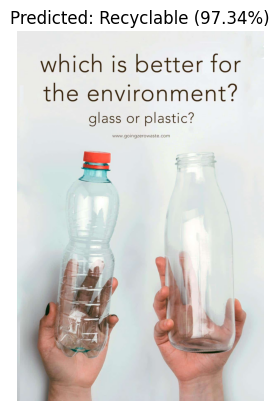

Class: Recyclable, Confidence: 97.34%

--- Non_Recyclable ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


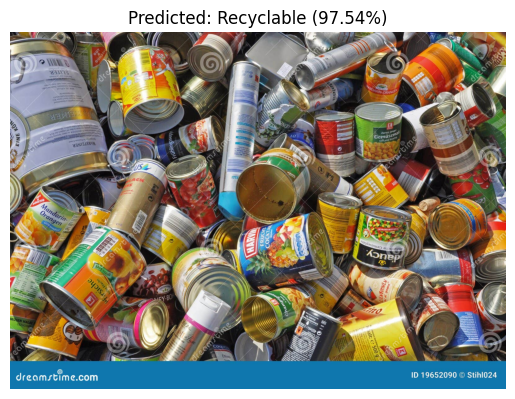

Class: Recyclable, Confidence: 97.54%

--- Organic ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


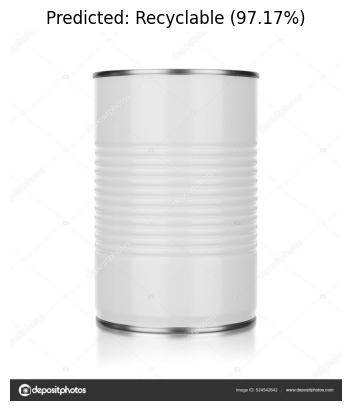

Class: Recyclable, Confidence: 97.17%

--- Recyclable ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


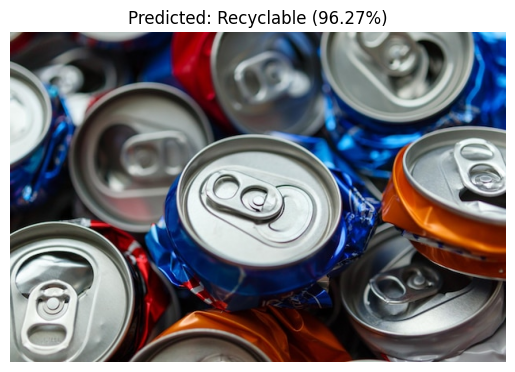

Class: Recyclable, Confidence: 96.27%
 Model saved!


In [ ]:
import random
class_names = ['Hazardous','Non_Recyclable','Organic','Recyclable']

def predict_waste(img_path):
    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)*100
    plt.imshow(load_img(img_path))
    plt.title(f'Predicted: {predicted_class} ({confidence:.2f}%)')
    plt.axis('off')
    plt.show()
    print(f"Class: {predicted_class}, Confidence: {confidence:.2f}%")

# Test all 4 classes
for cls in class_names:
    folder = f'/content/dataset_clean/Recyclable'
    images = os.listdir(folder)
    random.shuffle(images)
    print(f"\n--- {cls} ---")
    predict_waste(os.path.join(folder, images[0]))

# Save model
model.save('/content/drive/MyDrive/waste_model_clean.h5')
print(" Model saved!")

In [ ]:
!pip install gradio -q
import gradio as gr
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load model
model = load_model("/content/waste_model_clean.h5")

class_names = ['Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable']

def predict(img):
    if img is None:
        return None, "No image provided"

    original = img.copy()

    # Convert color (IMPORTANT for webcam)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize + normalize
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0]

    label = class_names[np.argmax(pred)]
    confidence = np.max(pred)

    text = f"{label} ({confidence*100:.2f}%)"

    # Draw on image
    cv2.putText(original, text, (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (0, 255, 0), 2)

    return original, text


#  FIXED INPUT (WEB + WEBCAM + PASTE)
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(
        sources=["upload", "webcam", "clipboard"],
        type="numpy"
    ),
    outputs=[
        gr.Image(label="Result"),
        gr.Textbox(label="Prediction")
    ],
    title="Smart Waste Classifier",
    description="Use Upload / Webcam / Paste → Click Submit"
)

#  IMPORTANT FOR WEBCAM IN COLAB
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b77e3df14619f86317.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
